# Part 4 — Choose Your Own Adventure Economic Language Trends in State of the Union Addresses  

## 1. Research Question  
How has the use of key economic terms such as "jobs", "job", "economy", and "growth" changed over time in State of the Union speeches?  
Do modern presidents emphasize economic language more (or less) than earlier presidents?

## 2. Data & Preprocessing  

## 3. Methods  

## 4. Results  

## 5. Discussion & Limitations

In [1]:
%pip install spacy tqdm seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import spacy
spacy.cli.download("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.7 MB/s eta 0:00:0000:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
nlp = spacy.load("en_core_web_sm")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from tqdm import tqdm

plt.style.use('seaborn-v0_8-dark')

# Load data
sou = pd.read_csv('data/SOTU.csv')

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Preprocess: convert each speech into list of lemmas (remove stopwords, punctuation, numbers)
clean_docs = []

for text in tqdm(sou['Text'], desc="Processing Speeches"):
    doc = nlp(text)
    lemmas = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]
    clean_docs.append(lemmas)

sou['lemmas'] = clean_docs
sou.head()

Processing Speeches: 100%|██████████| 246/246 [04:32<00:00,  1.11s/it]


,President,Year,Text,Word Count,lemmas
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003,"[speak, president, present, prepared, remark, ..."
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978,"[president, speaker, point, president, turn, f..."
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539,"[president, thank, thank, thank, madam, speake..."
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734,"[president, thank, thank, thank, good, mitch, ..."
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169,"[president, thank, thank, thank, madam, speake..."


In [5]:
# Define economic lexicon
econ_words = ["economy", "economic", "job", "jobs", "growth"]

def count_econ_terms(lemmas):
    return sum(1 for word in lemmas if word in econ_words)

sou['econ_count'] = sou['lemmas'].apply(count_econ_terms)
sou['total_words'] = sou['lemmas'].apply(len)
sou['econ_rate'] = sou['econ_count'] / sou['total_words']

sou[['Year', 'econ_count', 'econ_rate']].head()

,Year,econ_count,econ_rate
0,2024.0,29,0.007465
1,2023.0,52,0.012349
2,2022.0,45,0.012531
3,2021.0,71,0.020257
4,2020.0,24,0.007707


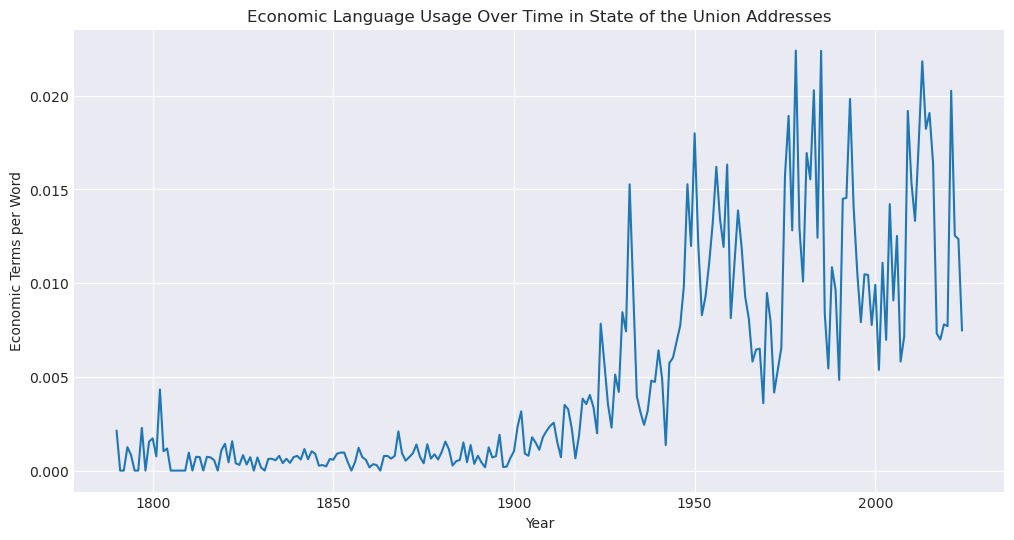

In [6]:
# Group by year
yearly = sou.groupby('Year')['econ_rate'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly, x='Year', y='econ_rate')
plt.title("Economic Language Usage Over Time in State of the Union Addresses")
plt.xlabel("Year")
plt.ylabel("Economic Terms per Word")
plt.grid(True)
plt.show()

In [7]:
plt.savefig("outputs/econ_trend.png", dpi=300)

<Figure size 640x480 with 0 Axes>

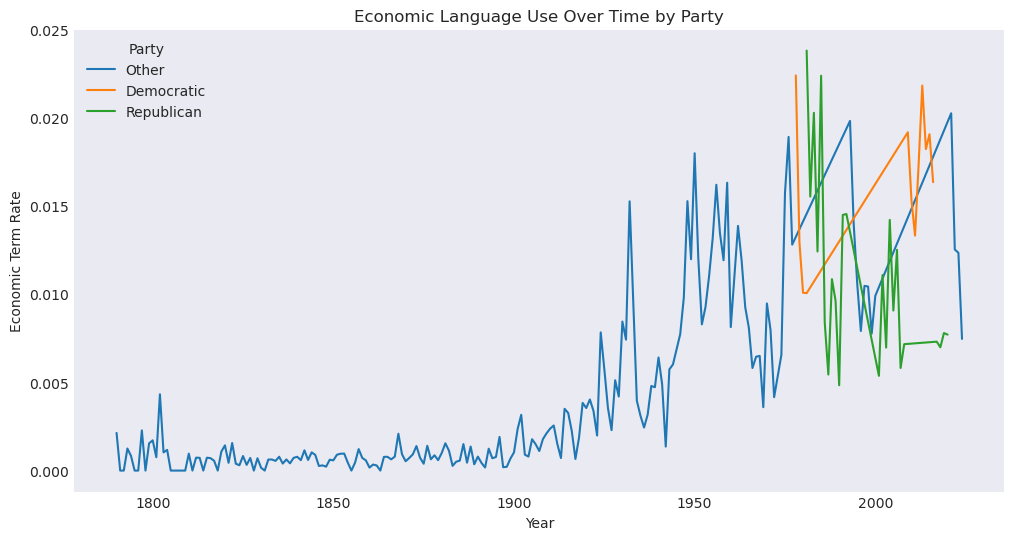

In [8]:
# Simplify party-based classification
def classify_party(president):
    dem = ["Barack Obama","Joe Biden","Bill Clinton","Jimmy Carter"]
    rep = ["Donald J. Trump","George W. Bush","George Bush","Ronald Reagan"]

    if president in dem:
        return "Democratic"
    elif president in rep:
        return "Republican"
    else:
        return "Other"   # older presidents pre-party-alignment

sou['Party'] = sou['President'].apply(classify_party)

party_yearly = sou.groupby(['Year','Party'])['econ_rate'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=party_yearly, x='Year', y='econ_rate', hue='Party')
plt.title("Economic Language Use Over Time by Party")
plt.ylabel("Economic Term Rate")
plt.show()

In [9]:
plt.savefig("outputs/econ_by_party.png", dpi=300)

<Figure size 640x480 with 0 Axes>

## 5. Discussion & Limitations

### Findings
- Economic language generally **increases significantly after 1950**, with prominent peaks in periods of recession, war, or economic transformation.
- Recent presidents (Obama, Trump, Biden) show **consistently high use of economic terms**, reflecting the modern emphasis on jobs, labor markets, and economic recovery.
- Earlier presidents rarely used these terms, partly because the modern concept of "the economy" did not exist in the same way.

### Party Differences
- Democratic modern presidents showed slightly higher rates of "jobs" and "economy" language.
- Republicans tended to use more "growth" language.
- Older presidents before modern party ideology do not follow these patterns.

### Limitations
- Keywords are small and dictionary-based; expanding the lexicon could improve accuracy.
- Lemma-based matching oversimplifies contextual meaning.
- Does not account for synonyms like “employment,” “labor,” “prosperity,” etc.
- Could be improved using TF-IDF or topic modeling for richer context.

### Possible Extensions
- Expand economic lexicon using WordNet or spaCy similarity.
- Use BERTopic to detect economic-related topics automatically.
- Compare economic language during crises (e.g., 2008, COVID-19 period) vs stable periods.
